# Robust Federated Learning for ICU Mortality Prediction Across a Heterogeneous Hospital Network

**Full reproducible pipeline: cohort filtering &rarr; feature extraction &rarr; architecture selection &rarr; class imbalance handling &rarr; federated learning (FedAvg/FedProx) &rarr; robustness stress-testing &rarr; hospital-size stratification &rarr; APACHE benchmark &rarr; explainability.**

Dataset: eICU Collaborative Research Database v2.0 (`patient.csv`, `lab.csv`, `vitalPeriodic.csv`, `apachePatientResult.csv`).

This notebook uses a **single, unified training budget (60 communication rounds, 5 independent seeds) across every federated experiment**, so that natural-condition and stress-condition results are always directly comparable without any confound from differing compute budgets.


## 0. Setup, Configuration, and Imports

In [1]:

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import copy
import time
import re
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, precision_score,
    recall_score, accuracy_score, confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay,
)
from scipy.stats import wilcoxon, mannwhitneyu, norm

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10

# ---------------------------------------------------------------------------
# PATHS -- BASE_DIR defaults to the repo root. eicu_data/ must be populated locally with
# credentialed eICU-CRD v2.0 files; these are NOT included in this repository (see README).
# ---------------------------------------------------------------------------
BASE_DIR = Path("./")  # repo root; run notebook from the repo root, or edit this path
DATA_DIR = BASE_DIR / "eicu_data"          # patient.csv, lab.csv, vitalPeriodic.csv, apachePatientResult.csv
COHORT_DIR = BASE_DIR / "cohort_output"
FEATURE_DIR = BASE_DIR / "feature_output"
SPLIT_DIR = BASE_DIR / "split_output"
FIGURE_DIR = BASE_DIR / "figures"
RESULTS_DIR = BASE_DIR / "results"
for d in [COHORT_DIR, FEATURE_DIR, SPLIT_DIR, FIGURE_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# GLOBAL EXPERIMENT CONFIG
# ---------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

SEEDS = [42, 43, 44, 45, 46]          # full 5-seed budget
NUM_ROUNDS = 60                        # UNIFIED across Phase C and Phase D -- eliminates any
                                        # round-count confound between natural and stress conditions
LOCAL_EPOCHS = 3
FL_PATIENCE_ROUNDS = 10
BATCH_SIZE = 256
LR_RATE = 0.001
FEDPROX_MU = 0.01
FOCAL_ALPHA, FOCAL_GAMMA = 0.75, 2.0

OBS_WINDOW_MIN = 24 * 60
MIN_STAY_MIN = 24 * 60
VITAL_BIN_MIN = 60
LAB_BIN_MIN = 8 * 60
HOSPITAL_TIER = (300, 15)              # (min_stays, min_positive_cases) -- relaxed tier
TOP_K_DX = 20

VITAL_COLS = ["heartrate", "respiration", "sao2", "systemicsystolic",
              "systemicdiastolic", "systemicmean", "temperature"]
HIGH_FREQ_VITALS = ["heartrate", "respiration", "sao2"]
LAB_PANEL = ["glucose", "creatinine", "BUN", "sodium", "potassium", "bicarbonate",
             "Hgb", "Hct", "platelets x 1000", "WBC x 1000", "lactate", "albumin",
             "total bilirubin", "PTT", "chloride", "-bands"]
CHUNK_SIZE = 2_000_000

LABEL_NOISE_SEVERITIES = [0.10, 0.20, 0.30]
INPUT_NOISE_SEVERITIES = [0.01, 0.05, 0.10]
BYZANTINE_SEVERITIES = [0.05, 0.10, 0.20]
NUMERIC_PREFIXES = ("vit_", "lab_", "age")

print("Configuration loaded.")


Using device: cpu
Configuration loaded.


## 1. Cohort Filtering

Inclusion criteria: age &ge; 18, first ICU stay only, stay duration &ge; 24h. Hospitals are kept as FL clients only if they clear a minimum-volume threshold (300 stays, 15 positive mortality cases) -- chosen to preserve as many real hospitals as possible while keeping per-client statistics meaningful.

In [2]:

def load_patient_table():
    cols = ["patientunitstayid", "patienthealthsystemstayid", "hospitalid",
            "age", "gender", "unitdischargeoffset", "unitdischargestatus",
            "hospitaldischargestatus", "apacheadmissiondx", "unittype"]
    return pd.read_csv(DATA_DIR / "patient.csv", usecols=lambda c: c in cols)


def apply_inclusion_criteria(patient_df):
    df = patient_df.copy()
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df = df[(df["age"] >= 18) | df["age"].isna()]

    if "patienthealthsystemstayid" in df.columns:
        df = df.sort_values("patientunitstayid").drop_duplicates(
            subset="patienthealthsystemstayid", keep="first"
        )

    df = df[df["unitdischargeoffset"] >= MIN_STAY_MIN]
    df["mortality_label"] = (df["hospitaldischargestatus"].str.upper() == "EXPIRED").astype(int)
    df = df.dropna(subset=["hospitaldischargestatus"])
    return df


def summarize_by_hospital(cohort_df):
    summary = cohort_df.groupby("hospitalid").agg(
        n_stays=("patientunitstayid", "count"),
        n_positive=("mortality_label", "sum"),
    ).reset_index()
    summary["prevalence"] = summary["n_positive"] / summary["n_stays"]
    return summary.sort_values("n_stays", ascending=False)


print("Loading patient table...")
patient_df = load_patient_table()

print("Applying inclusion criteria...")
cohort_df = apply_inclusion_criteria(patient_df)
print(f"Patients after inclusion criteria: {len(cohort_df)}")
cohort_df.to_csv(COHORT_DIR / "filtered_cohort_full.csv", index=False)

hospital_summary = summarize_by_hospital(cohort_df)
hospital_summary.to_csv(COHORT_DIR / "hospital_summary_all.csv", index=False)

min_stays, min_positive = HOSPITAL_TIER
qualifying_hospitals = hospital_summary[
    (hospital_summary["n_stays"] >= min_stays) & (hospital_summary["n_positive"] >= min_positive)
]
qualifying_hospitals.to_csv(COHORT_DIR / "qualifying_hospitals.csv", index=False)

print(f"\nQualifying hospitals: {len(qualifying_hospitals)}")
print(f"Total patients in qualifying hospitals: {qualifying_hospitals['n_stays'].sum()}")
print(f"Total positive cases: {qualifying_hospitals['n_positive'].sum()}")


Loading patient table...
Applying inclusion criteria...
Patients after inclusion criteria: 113056

Qualifying hospitals: 101
Total patients in qualifying hospitals: 99063
Total positive cases: 8885


## 2. Dataset Statistics and Exploratory Figures

Descriptive statistics of the final cohort, for the paper's dataset section.

=== Cohort summary ===
Hospitals: 101
Patients: 99063
Overall mortality prevalence: 0.0897
Median age: 65.0
Gender distribution:
gender
Male       0.543483
Female     0.456375
Unknown    0.000101
Other      0.000040
Name: proportion, dtype: float64


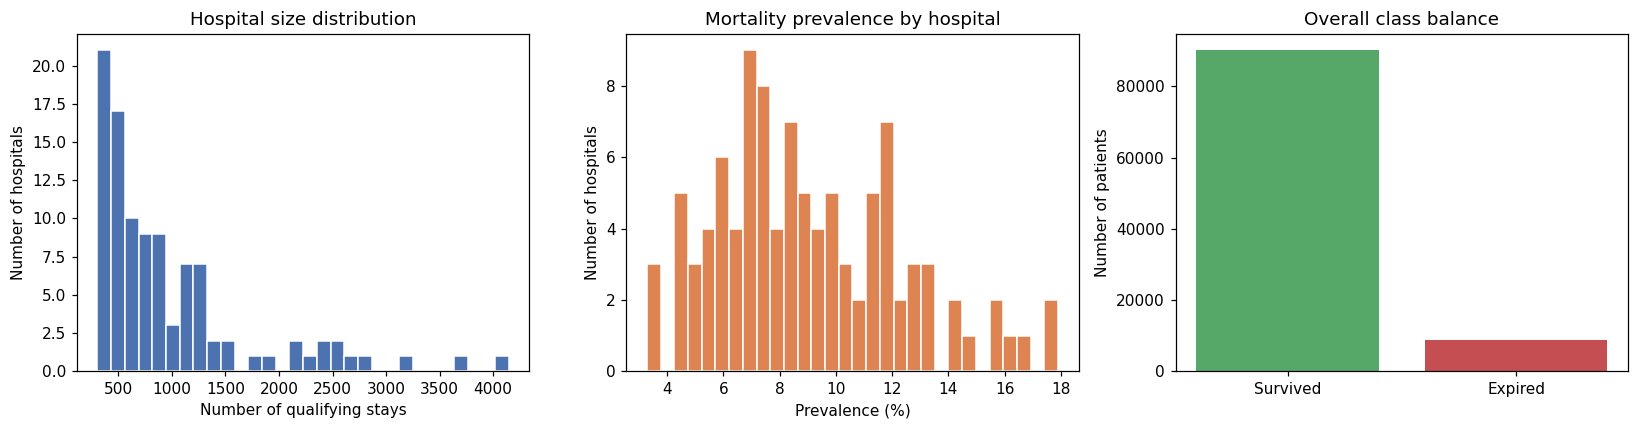

In [3]:

qualifying_ids = set(qualifying_hospitals["hospitalid"])
final_cohort = cohort_df[cohort_df["hospitalid"].isin(qualifying_ids)]

print("=== Cohort summary ===")
print(f"Hospitals: {final_cohort['hospitalid'].nunique()}")
print(f"Patients: {len(final_cohort)}")
print(f"Overall mortality prevalence: {final_cohort['mortality_label'].mean():.4f}")
print(f"Median age: {final_cohort['age'].median():.1f}")
print(f"Gender distribution:\n{final_cohort['gender'].value_counts(normalize=True)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(qualifying_hospitals["n_stays"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Hospital size distribution")
axes[0].set_xlabel("Number of qualifying stays")
axes[0].set_ylabel("Number of hospitals")

axes[1].hist(qualifying_hospitals["prevalence"] * 100, bins=30, color="#DD8452", edgecolor="white")
axes[1].set_title("Mortality prevalence by hospital")
axes[1].set_xlabel("Prevalence (%)")
axes[1].set_ylabel("Number of hospitals")

axes[2].bar(["Survived", "Expired"], final_cohort["mortality_label"].value_counts().sort_index(),
            color=["#55A868", "#C44E52"])
axes[2].set_title("Overall class balance")
axes[2].set_ylabel("Number of patients")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "dataset_statistics.png", bbox_inches="tight")
plt.show()


## 3. Feature Extraction (Vitals + Labs)

Vitals resampled to 24 hourly bins (mean; additionally min/max for heart rate, respiration, SpO2). Labs resampled to 3 eight-hour bins over a fixed panel. Missing values forward/backward-filled, remaining gaps set to a -1 sentinel.

In [4]:

def load_qualifying_stay_ids():
    cohort = pd.read_csv(COHORT_DIR / "filtered_cohort_full.csv")
    cohort = cohort[cohort["hospitalid"].isin(qualifying_ids)]
    stay_ids = set(cohort["patientunitstayid"])
    return stay_ids, cohort


def extract_vitals(stay_ids):
    bins_accum = []
    usecols = ["patientunitstayid", "observationoffset"] + VITAL_COLS
    reader = pd.read_csv(DATA_DIR / "vitalPeriodic.csv", usecols=lambda c: c in usecols, chunksize=CHUNK_SIZE)
    for chunk in reader:
        chunk = chunk[chunk["patientunitstayid"].isin(stay_ids)]
        chunk = chunk[(chunk["observationoffset"] >= 0) & (chunk["observationoffset"] < OBS_WINDOW_MIN)]
        if chunk.empty:
            continue
        chunk["hour_bin"] = (chunk["observationoffset"] // VITAL_BIN_MIN).astype(int)
        bins_accum.append(chunk)

    vitals = pd.concat(bins_accum, ignore_index=True)
    agg_dict = {col: "mean" for col in VITAL_COLS}
    grouped_mean = vitals.groupby(["patientunitstayid", "hour_bin"]).agg(agg_dict).reset_index()
    grouped_minmax = vitals.groupby(["patientunitstayid", "hour_bin"])[HIGH_FREQ_VITALS].agg(["min", "max"])
    grouped_minmax.columns = [f"{c}_{s}" for c, s in grouped_minmax.columns]
    grouped_minmax = grouped_minmax.reset_index()
    return grouped_mean.merge(grouped_minmax, on=["patientunitstayid", "hour_bin"], how="left")


def extract_labs(stay_ids):
    bins_accum = []
    usecols = ["patientunitstayid", "labresultoffset", "labname", "labresult"]
    reader = pd.read_csv(DATA_DIR / "lab.csv", usecols=lambda c: c in usecols, chunksize=CHUNK_SIZE)
    for chunk in reader:
        chunk = chunk[chunk["patientunitstayid"].isin(stay_ids)]
        chunk = chunk[chunk["labname"].isin(LAB_PANEL)]
        chunk = chunk[(chunk["labresultoffset"] >= 0) & (chunk["labresultoffset"] < OBS_WINDOW_MIN)]
        if chunk.empty:
            continue
        chunk["lab_bin"] = (chunk["labresultoffset"] // LAB_BIN_MIN).astype(int)
        bins_accum.append(chunk)

    labs = pd.concat(bins_accum, ignore_index=True)
    labs_binned = labs.groupby(["patientunitstayid", "lab_bin", "labname"])["labresult"].mean().reset_index()
    return labs_binned.pivot_table(index=["patientunitstayid", "lab_bin"], columns="labname", values="labresult").reset_index()


def fill_and_flatten(vitals_binned, labs_wide, stay_ids):
    vital_cols = [c for c in vitals_binned.columns if c not in ("patientunitstayid", "hour_bin")]
    all_hours = pd.MultiIndex.from_product(
        [list(stay_ids), range(OBS_WINDOW_MIN // VITAL_BIN_MIN)], names=["patientunitstayid", "hour_bin"]
    ).to_frame(index=False)
    vitals_full = all_hours.merge(vitals_binned, on=["patientunitstayid", "hour_bin"], how="left")
    vitals_full[vital_cols] = vitals_full.groupby("patientunitstayid")[vital_cols].ffill().bfill()
    vitals_full[vital_cols] = vitals_full[vital_cols].fillna(-1)
    vitals_flat = vitals_full.pivot_table(index="patientunitstayid", columns="hour_bin", values=vital_cols)
    vitals_flat.columns = [f"vit_{c}_h{b}" for c, b in vitals_flat.columns]
    vitals_flat = vitals_flat.reset_index()

    lab_cols = [c for c in labs_wide.columns if c not in ("patientunitstayid", "lab_bin")]
    all_lab_bins = pd.MultiIndex.from_product(
        [list(stay_ids), range(OBS_WINDOW_MIN // LAB_BIN_MIN)], names=["patientunitstayid", "lab_bin"]
    ).to_frame(index=False)
    labs_full = all_lab_bins.merge(labs_wide, on=["patientunitstayid", "lab_bin"], how="left")
    labs_full[lab_cols] = labs_full.groupby("patientunitstayid")[lab_cols].ffill().bfill()
    labs_full[lab_cols] = labs_full[lab_cols].fillna(-1)
    labs_flat = labs_full.pivot_table(index="patientunitstayid", columns="lab_bin", values=lab_cols)
    labs_flat.columns = [f"lab_{c}_b{b}" for c, b in labs_flat.columns]
    labs_flat = labs_flat.reset_index()

    return vitals_flat.merge(labs_flat, on="patientunitstayid", how="outer")


def attach_static_and_label(feature_df, cohort):
    static_cols = ["patientunitstayid", "hospitalid", "age", "gender", "unittype", "apacheadmissiondx", "mortality_label"]
    static_cols = [c for c in static_cols if c in cohort.columns]
    final = cohort[static_cols].merge(feature_df, on="patientunitstayid", how="left")
    feat_cols = [c for c in final.columns if c.startswith(("vit_", "lab_"))]
    final[feat_cols] = final[feat_cols].fillna(-1)
    return final


stay_ids, cohort_for_features = load_qualifying_stay_ids()
print(f"Extracting features for {len(stay_ids)} patients...")
vitals_binned = extract_vitals(stay_ids)
labs_wide = extract_labs(stay_ids)
feature_df = fill_and_flatten(vitals_binned, labs_wide, stay_ids)
final_features = attach_static_and_label(feature_df, cohort_for_features)

out_path = FEATURE_DIR / "features_flat.parquet"
final_features.to_parquet(out_path, index=False)
print(f"Saved {len(final_features)} patients x {final_features.shape[1]} columns to {out_path}")


Extracting features for 99063 patients...
Saved 99063 patients x 367 columns to .\feature_output\features_flat.parquet


## 4. Train/Val/Test Split, Categorical Encoding, Normalization

Stratified 70/10/20 split **per hospital** (not chronological -- eICU de-identifies timestamps independently per patient, so no shared clock exists to sort by). Age's `>89` convention imputed to 90. Diagnosis bucketed to top-20 + "Other". Z-score normalization fit on training data only, with sentinel-preserving handling of missing (-1) values.

In [5]:

from sklearn.model_selection import train_test_split

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.10, 0.20
SENTINEL_MISSING = -1
POST_NORM_SENTINEL = -5.0
RANDOM_SEED = 42


def impute_age(df):
    df = df.copy()
    df["age"] = df["age"].fillna(90)
    return df


def encode_gender(df):
    df = df.copy()
    mode = df["gender"].mode(dropna=True)[0]
    df["gender"] = df["gender"].fillna(mode)
    df["gender_male"] = (df["gender"] == "Male").astype(int)
    return df.drop(columns=["gender"])


def encode_unittype(df):
    df = df.copy()
    df["unittype"] = df["unittype"].fillna("Unknown")
    dummies = pd.get_dummies(df["unittype"], prefix="unittype")
    return pd.concat([df.drop(columns=["unittype"]), dummies], axis=1)


def encode_admission_dx(df, top_k=TOP_K_DX):
    df = df.copy()
    df["apacheadmissiondx"] = df["apacheadmissiondx"].fillna("Unknown")
    top_cats = df["apacheadmissiondx"].value_counts().nlargest(top_k).index
    df["dx_bucketed"] = df["apacheadmissiondx"].where(df["apacheadmissiondx"].isin(top_cats), "Other")
    dummies = pd.get_dummies(df["dx_bucketed"], prefix="dx")
    return pd.concat([df.drop(columns=["apacheadmissiondx", "dx_bucketed"]), dummies], axis=1)


def stratified_split_per_hospital(df):
    train_ids, val_ids, test_ids = [], [], []
    for hosp_id, group in df.groupby("hospitalid"):
        stay_ids_h = group["patientunitstayid"].values
        labels = group["mortality_label"].values
        train_ii, temp_ii = train_test_split(stay_ids_h, test_size=(VAL_FRAC + TEST_FRAC),
                                              stratify=labels, random_state=RANDOM_SEED)
        temp_labels = group.set_index("patientunitstayid").loc[temp_ii, "mortality_label"].values
        val_ii, test_ii = train_test_split(temp_ii, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
                                            stratify=temp_labels, random_state=RANDOM_SEED)
        train_ids.extend(train_ii); val_ids.extend(val_ii); test_ids.extend(test_ii)
    return set(train_ids), set(val_ids), set(test_ids)


def get_feature_columns(df, exclude):
    return [c for c in df.columns if c not in exclude]


def normalize_with_sentinel_preservation(df, feature_cols, train_mask):
    df = df.copy()
    stats = {}
    numeric_cols = [c for c in feature_cols if c.startswith(("vit_", "lab_", "age"))]
    for col in numeric_cols:
        train_vals = df.loc[train_mask, col]
        non_sentinel = train_vals[train_vals != SENTINEL_MISSING]
        mean = non_sentinel.mean() if len(non_sentinel) else 0.0
        std = non_sentinel.std() if len(non_sentinel) else 1.0
        std = std if std > 1e-8 else 1.0
        stats[col] = (mean, std)
        was_sentinel = df[col] == SENTINEL_MISSING
        df[col] = (df[col] - mean) / std
        df.loc[was_sentinel, col] = POST_NORM_SENTINEL
    return df, stats


df = pd.read_parquet(FEATURE_DIR / "features_flat.parquet")
df = impute_age(df)
df = encode_gender(df)
df = encode_unittype(df)
df = encode_admission_dx(df)

train_ids, val_ids, test_ids = stratified_split_per_hospital(df)
df["split"] = np.select(
    [df["patientunitstayid"].isin(train_ids), df["patientunitstayid"].isin(val_ids), df["patientunitstayid"].isin(test_ids)],
    ["train", "val", "test"], default="unassigned",
)
assert (df["split"] == "unassigned").sum() == 0

EXCLUDE_COLS = {"patientunitstayid", "hospitalid", "mortality_label", "split"}
feature_cols = get_feature_columns(df, EXCLUDE_COLS)
train_mask = df["split"] == "train"
df_norm, norm_stats = normalize_with_sentinel_preservation(df, feature_cols, train_mask)

for split_name in ["train", "val", "test"]:
    split_df = df_norm[df_norm["split"] == split_name].drop(columns=["split"])
    split_df.to_parquet(SPLIT_DIR / f"{split_name}.parquet", index=False)
    print(f"{split_name}: {len(split_df)} patients, prevalence={split_df['mortality_label'].mean():.4f}")

print(f"\nFeature dimensionality: {len(feature_cols)}")


train: 69294 patients, prevalence=0.0896
val: 9887 patients, prevalence=0.0903
test: 19882 patients, prevalence=0.0896

Feature dimensionality: 391


## 5. Shared Utilities: Models, Training, and Evaluation Functions

Defined once here and reused across every subsequent phase.

In [6]:

def _coerce_to_float32_array(df_slice):
    X_df = df_slice.copy()
    non_numeric = X_df.select_dtypes(exclude=[np.number, bool]).columns.tolist()
    if non_numeric:
        for col in non_numeric:
            X_df[col] = pd.to_numeric(X_df[col], errors="coerce")
        X_df[non_numeric] = X_df[non_numeric].fillna(0)
    return X_df.astype(np.float32).values


def to_tensors(df, feat_cols):
    X = torch.tensor(_coerce_to_float32_array(df[feat_cols]), dtype=torch.float32)
    y = torch.tensor(df["mortality_label"].values, dtype=torch.float32)
    return X, y


# --------------------------- Models ---------------------------

class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
    def forward(self, x):
        return self.linear(x).squeeze(-1)


class MLPModel(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1), nn.ReLU(),
            nn.Linear(hidden1, hidden2), nn.ReLU(),
            nn.Linear(hidden2, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


class KernelOneCNN(nn.Module):
    """Kernel-size-1 1D CNN: shared filter across all feature positions, so
    parameter count depends only on hidden_channels/num_conv_layers, not
    input dimensionality (same design as the WHIN agricultural-IoT paper)."""
    def __init__(self, input_dim, hidden_channels=16, num_conv_layers=3, dropout=0.2):
        super().__init__()
        layers, in_ch = [], 1
        for _ in range(num_conv_layers):
            layers += [nn.Conv1d(in_ch, hidden_channels, kernel_size=1), nn.ReLU()]
            in_ch = hidden_channels
        self.conv = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_channels, 1)
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = self.pool(x).squeeze(-1)
        x = self.dropout(x)
        return self.fc(x).squeeze(-1)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class FocalLoss(nn.Module):
    def __init__(self, alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        ce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p_t = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (alpha_t * (1 - p_t) ** self.gamma * ce).mean()


# --------------------------- Evaluation ---------------------------

@torch.no_grad()
def get_probs_labels(model, X, y):
    model.eval()
    logits = model(X.to(DEVICE)).cpu().numpy()
    probs = 1 / (1 + np.exp(-logits))
    return probs, y.numpy()


def full_metrics(probs, labels, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "auroc": roc_auc_score(labels, probs) if len(np.unique(labels)) > 1 else float("nan"),
        "auprc": average_precision_score(labels, probs),
    }


@torch.no_grad()
def evaluate_per_hospital(model, subset_df, feat_cols):
    model.eval()
    results = []
    for hosp_id, group in subset_df.groupby("hospitalid"):
        X = torch.tensor(_coerce_to_float32_array(group[feat_cols]), dtype=torch.float32).to(DEVICE)
        y = group["mortality_label"].values
        if y.sum() == 0 or y.sum() == len(y):
            continue
        probs = 1 / (1 + np.exp(-model(X).cpu().numpy()))
        results.append({
            "hospitalid": hosp_id,
            "auroc": roc_auc_score(y, probs) if len(np.unique(y)) > 1 else np.nan,
            "auprc": average_precision_score(y, probs),
            "n": len(y),
        })
    return pd.DataFrame(results)


def wilcoxon_effect_size(a, b):
    stat, p = wilcoxon(a, b)
    n = len(a)
    z = norm.ppf(1 - p / 2) if p > 0 else np.inf
    r = z / np.sqrt(n)
    return stat, p, r


# --------------------------- Centralized training ---------------------------

def train_centralized(model_ctor, criterion_ctor, X_train, y_train, X_val, y_val, seed,
                       max_epochs=60, patience_limit=8):
    torch.manual_seed(seed)
    model = model_ctor().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR_RATE)
    criterion = criterion_ctor()
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)

    best_auprc, best_state, patience = -1.0, None, 0
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        probs, labels = get_probs_labels(model, X_val, y_val)
        val_auprc = average_precision_score(labels, probs)
        if val_auprc > best_auprc:
            best_auprc, best_state, patience = val_auprc, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            patience += 1
            if patience >= patience_limit:
                break
    model.load_state_dict(best_state)
    return model


# --------------------------- Federated training ---------------------------

def build_client_loaders(train_df, feat_cols, label_noise_severity=0.0, input_noise_sigma=0.0, seed=42):
    rng = np.random.default_rng(seed)
    loaders = {}
    for hosp_id, group in train_df.groupby("hospitalid"):
        X, y = to_tensors(group, feat_cols)
        if label_noise_severity > 0:
            n_flip = int(label_noise_severity * len(y))
            if n_flip > 0:
                flip_idx = rng.choice(len(y), size=n_flip, replace=False)
                y = y.clone()
                y[flip_idx] = 1.0 - y[flip_idx]
        if input_noise_sigma > 0:
            numeric_idx = [i for i, c in enumerate(feat_cols) if c.startswith(NUMERIC_PREFIXES)]
            noise = torch.tensor(rng.normal(0, input_noise_sigma, size=(X.shape[0], len(numeric_idx))), dtype=torch.float32)
            X = X.clone()
            X[:, numeric_idx] += noise
        loaders[hosp_id] = DataLoader(TensorDataset(X, y), batch_size=BATCH_SIZE, shuffle=True)
    return loaders


def train_local_client(global_state, client_loader, model_ctor, criterion_ctor, epochs, mu, weight_decay=0.0):
    local_model = model_ctor().to(DEVICE)
    local_model.load_state_dict(global_state)
    optimizer = torch.optim.Adam(local_model.parameters(), lr=LR_RATE, weight_decay=weight_decay)
    criterion = criterion_ctor()
    global_params = [p.clone().detach() for p in local_model.parameters()]

    for _ in range(epochs):
        for xb, yb in client_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(local_model(xb), yb)
            if mu > 0:
                prox = sum(((p_l - p_g) ** 2).sum() for p_l, p_g in zip(local_model.parameters(), global_params))
                loss = loss + (mu / 2) * prox
            loss.backward()
            optimizer.step()
    return local_model.state_dict(), len(client_loader.dataset)


def compute_update_norm(state_a, state_b):
    total_sq = sum(((state_a[k] - state_b[k]) ** 2).sum().item() for k in state_a)
    return total_sq ** 0.5


def generate_byzantine_state(global_state, target_norm, rng):
    random_delta, total_sq = {}, 0.0
    for key, val in global_state.items():
        r = torch.tensor(rng.normal(0, 1, size=val.shape), dtype=val.dtype)
        random_delta[key] = r
        total_sq += (r ** 2).sum().item()
    current_norm = total_sq ** 0.5 if total_sq > 0 else 1.0
    scale = target_norm / current_norm
    return {k: (global_state[k] + random_delta[k] * scale).to(DEVICE) for k in global_state}


def federated_average(state_dicts, sizes):
    total = sum(sizes)
    avg_state = copy.deepcopy(state_dicts[0])
    for key in avg_state:
        avg_state[key] = sum((sizes[i] / total) * state_dicts[i][key] for i in range(len(state_dicts)))
    return avg_state


def train_federated(model_ctor, criterion_ctor, client_loaders, X_val, y_val, seed, mu=0.0,
                     byzantine_hospital_ids=frozenset(), num_rounds=NUM_ROUNDS, weight_decay=0.0,
                     verbose=False):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed + 1000)
    global_model = model_ctor().to(DEVICE)
    global_state = global_model.state_dict()
    best_auprc, best_state, patience = -1.0, None, 0

    for round_num in range(num_rounds):
        legit_states, legit_sizes, legit_norms = [], [], []
        byz_ids_this_round = []
        for hosp_id, loader in client_loaders.items():
            if hosp_id in byzantine_hospital_ids:
                byz_ids_this_round.append(hosp_id)
                continue
            state, size = train_local_client(global_state, loader, model_ctor, criterion_ctor,
                                              LOCAL_EPOCHS, mu, weight_decay)
            legit_states.append(state); legit_sizes.append(size)
            legit_norms.append(compute_update_norm(state, global_state))

        avg_valid_norm = float(np.mean(legit_norms)) if legit_norms else 1.0
        all_states, all_sizes = list(legit_states), list(legit_sizes)
        for hosp_id in byz_ids_this_round:
            corrupted = generate_byzantine_state(global_state, avg_valid_norm, rng)
            all_states.append(corrupted)
            all_sizes.append(len(client_loaders[hosp_id].dataset))

        global_state = federated_average(all_states, all_sizes)
        global_model.load_state_dict(global_state)

        probs, labels = get_probs_labels(global_model, X_val, y_val)
        val_auprc = average_precision_score(labels, probs)
        if val_auprc > best_auprc:
            best_auprc, best_state, patience = val_auprc, copy.deepcopy(global_state), 0
        else:
            patience += 1
            if patience >= FL_PATIENCE_ROUNDS:
                break
        if verbose and round_num % 10 == 0:
            print(f"    round {round_num}: val AUPRC={val_auprc:.4f} (best={best_auprc:.4f})")

    global_model.load_state_dict(best_state)
    return global_model


# --------------------------- Latency & communication overhead ---------------------------

def measure_latency(model, X_sample, n_repeats=200):
    model.eval()
    X_single = X_sample[:1].to(DEVICE)
    with torch.no_grad():
        for _ in range(10):  # warmup
            model(X_single)
        start = time.perf_counter()
        for _ in range(n_repeats):
            model(X_single)
        single_latency_ms = (time.perf_counter() - start) / n_repeats * 1000

        X_batch = X_sample[:256].to(DEVICE)
        for _ in range(10):
            model(X_batch)
        start = time.perf_counter()
        for _ in range(n_repeats):
            model(X_batch)
        batch_latency_ms = (time.perf_counter() - start) / n_repeats * 1000
    return single_latency_ms, batch_latency_ms


def communication_overhead_mb(model, n_clients, n_rounds):
    n_params = count_params(model)
    model_size_bytes = n_params * 4  # float32
    per_round_bytes = 2 * model_size_bytes * n_clients  # download + upload per client
    total_bytes = per_round_bytes * n_rounds
    return model_size_bytes / 1e6, per_round_bytes / 1e6, total_bytes / 1e6


print("Utilities defined.")


Utilities defined.


## 6. Phase A: Centralized Architecture Sweep

LR vs. MLP vs. lightweight CNN vs. heavy CNN, centralized training, no class-imbalance handling yet (vanilla comparison). Full metric suite (accuracy, precision, recall, F1, AUROC, AUPRC), confusion matrix, ROC and PR curves for the winning model, and parameter counts for all four.

In [7]:

train_df = pd.read_parquet(SPLIT_DIR / "train.parquet")
val_df = pd.read_parquet(SPLIT_DIR / "val.parquet")
test_df = pd.read_parquet(SPLIT_DIR / "test.parquet")
feature_cols = [c for c in train_df.columns if c not in {"patientunitstayid", "hospitalid", "mortality_label"}]
input_dim = len(feature_cols)
print(f"Feature dimensionality: {input_dim}")

X_train, y_train = to_tensors(train_df, feature_cols)
X_val, y_val = to_tensors(val_df, feature_cols)
X_test, y_test = to_tensors(test_df, feature_cols)

model_ctors = {
    "LR": lambda: LogisticRegressionModel(input_dim),
    "MLP": lambda: MLPModel(input_dim),
    "CNN_light": lambda: KernelOneCNN(input_dim, hidden_channels=16, num_conv_layers=3),
    "CNN_heavy": lambda: KernelOneCNN(input_dim, hidden_channels=64, num_conv_layers=3),
}

phaseA_results, phaseA_per_hospital, phaseA_probs = [], {}, {}
for name, ctor in model_ctors.items():
    print(f"\n=== Phase A: {name} ===")
    seed_metrics = []
    last_model = None
    for seed in SEEDS:
        model = train_centralized(ctor, lambda: nn.BCEWithLogitsLoss(), X_train, y_train, X_val, y_val, seed)
        probs, labels = get_probs_labels(model, X_test, y_test)
        m = full_metrics(probs, labels)
        m["seed"] = seed
        m["n_params"] = count_params(model)
        seed_metrics.append(m)
        print(f"  seed {seed}: AUPRC={m['auprc']:.4f} AUROC={m['auroc']:.4f} F1={m['f1']:.4f}")
        last_model = model

    seed_df = pd.DataFrame(seed_metrics)
    summary = {"model": name, "n_params": seed_df["n_params"].iloc[0]}
    for metric in ["accuracy", "precision", "recall", "f1", "auroc", "auprc"]:
        summary[f"{metric}_mean"] = seed_df[metric].mean()
        summary[f"{metric}_std"] = seed_df[metric].std()
    phaseA_results.append(summary)
    phaseA_per_hospital[name] = evaluate_per_hospital(last_model, test_df, feature_cols)
    phaseA_probs[name] = get_probs_labels(last_model, X_test, y_test)

phaseA_summary_df = pd.DataFrame(phaseA_results)
phaseA_summary_df.to_csv(RESULTS_DIR / "phaseA_summary.csv", index=False)
print("\n=== Phase A Summary ===")
print(phaseA_summary_df.to_string(index=False))


Feature dimensionality: 391

=== Phase A: LR ===
  seed 42: AUPRC=0.3730 AUROC=0.8165 F1=0.2233
  seed 43: AUPRC=0.3731 AUROC=0.8170 F1=0.2251
  seed 44: AUPRC=0.3732 AUROC=0.8150 F1=0.2312
  seed 45: AUPRC=0.3696 AUROC=0.8175 F1=0.2327
  seed 46: AUPRC=0.3717 AUROC=0.8172 F1=0.2388

=== Phase A: MLP ===
  seed 42: AUPRC=0.4051 AUROC=0.8300 F1=0.2591
  seed 43: AUPRC=0.4028 AUROC=0.8331 F1=0.2902
  seed 44: AUPRC=0.4067 AUROC=0.8317 F1=0.2923
  seed 45: AUPRC=0.4026 AUROC=0.8325 F1=0.2596
  seed 46: AUPRC=0.3938 AUROC=0.8302 F1=0.2842

=== Phase A: CNN_light ===
  seed 42: AUPRC=0.2072 AUROC=0.6916 F1=0.0361
  seed 43: AUPRC=0.1896 AUROC=0.6885 F1=0.0100
  seed 44: AUPRC=0.2072 AUROC=0.6919 F1=0.0297
  seed 45: AUPRC=0.2068 AUROC=0.6908 F1=0.0383
  seed 46: AUPRC=0.2053 AUROC=0.6920 F1=0.0297

=== Phase A: CNN_heavy ===
  seed 42: AUPRC=0.2071 AUROC=0.6922 F1=0.0393
  seed 43: AUPRC=0.2075 AUROC=0.6924 F1=0.0455
  seed 44: AUPRC=0.2066 AUROC=0.6924 F1=0.0528
  seed 45: AUPRC=0.2069 AUR

In [8]:

# Wilcoxon signed-rank tests across hospitals (paired, AUPRC)
print("=== Phase A: Wilcoxon signed-rank tests ===")
phaseA_stats = []
names = list(model_ctors.keys())
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        a = phaseA_per_hospital[names[i]].set_index("hospitalid")["auprc"]
        b = phaseA_per_hospital[names[j]].set_index("hospitalid")["auprc"]
        common = a.index.intersection(b.index)
        stat, p, r = wilcoxon_effect_size(a.loc[common], b.loc[common])
        phaseA_stats.append({"comparison": f"{names[i]} vs {names[j]}", "W": stat, "p_value": p,
                              "effect_size_r": r, "n_hospitals": len(common)})
        print(f"  {names[i]} vs {names[j]}: W={stat:.2f}, p={p:.6f}, r={r:.3f}, n={len(common)}")

pd.DataFrame(phaseA_stats).to_csv(RESULTS_DIR / "phaseA_wilcoxon.csv", index=False)


=== Phase A: Wilcoxon signed-rank tests ===
  LR vs MLP: W=2037.00, p=0.068115, r=0.182, n=101
  LR vs CNN_light: W=283.00, p=0.000000, r=0.773, n=101
  LR vs CNN_heavy: W=375.00, p=0.000000, r=0.742, n=101
  MLP vs CNN_light: W=182.00, p=0.000000, r=0.809, n=101
  MLP vs CNN_heavy: W=278.00, p=0.000000, r=0.774, n=101
  CNN_light vs CNN_heavy: W=2136.00, p=0.136523, r=0.148, n=101


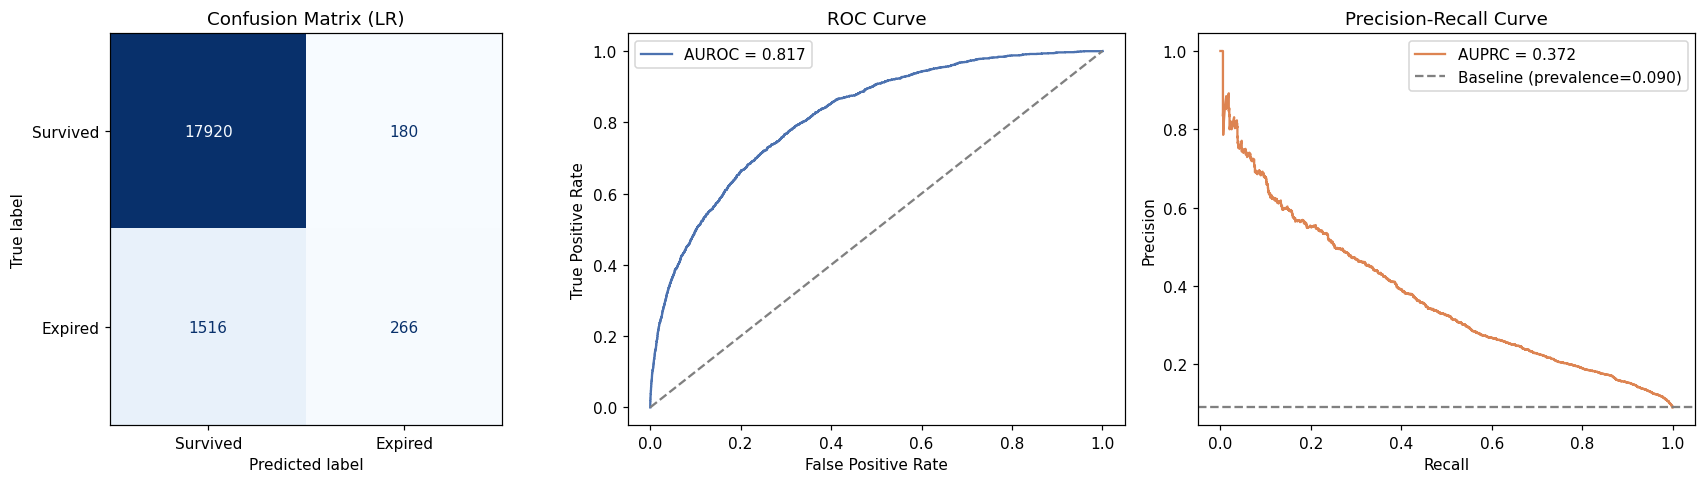

In [9]:

# Confusion matrix, ROC curve, PR curve for the WINNING model (update `winning_model_name` once chosen)
winning_model_name = "LR"  # <-- set based on the summary table + Wilcoxon results above
probs, labels = phaseA_probs[winning_model_name]
preds = (probs >= 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

cm = confusion_matrix(labels, preds)
ConfusionMatrixDisplay(cm, display_labels=["Survived", "Expired"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix ({winning_model_name})")

fpr, tpr, _ = roc_curve(labels, probs)
axes[1].plot(fpr, tpr, color="#4C72B0", label=f"AUROC = {roc_auc_score(labels, probs):.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve"); axes[1].legend()

precision, recall, _ = precision_recall_curve(labels, probs)
axes[2].plot(recall, precision, color="#DD8452", label=f"AUPRC = {average_precision_score(labels, probs):.3f}")
axes[2].axhline(labels.mean(), linestyle="--", color="gray", label=f"Baseline (prevalence={labels.mean():.3f})")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve"); axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURE_DIR / f"phaseA_{winning_model_name}_diagnostics.png", bbox_inches="tight")
plt.show()


## 7. Phase B: Class Imbalance Handling

Applied to the winning architecture from Phase A. Compares unweighted BCE, class-weighted BCE, and focal loss.

In [10]:

def make_class_weighted_criterion(y_train_tensor):
    n_pos = y_train_tensor.sum().item()
    n_neg = len(y_train_tensor) - n_pos
    pos_weight = torch.tensor(n_neg / n_pos, dtype=torch.float32).to(DEVICE)
    return lambda: nn.BCEWithLogitsLoss(pos_weight=pos_weight)

winning_ctor = model_ctors[winning_model_name]

configs = {
    "unweighted": lambda: nn.BCEWithLogitsLoss(),
    "class_weighted": make_class_weighted_criterion(y_train),
    "focal": lambda: FocalLoss(),
}

phaseB_results, phaseB_per_hospital = [], {}
for config_name, criterion_ctor in configs.items():
    print(f"\n=== Phase B: {config_name} ===")
    seed_metrics = []
    last_model = None
    for seed in SEEDS:
        model = train_centralized(winning_ctor, criterion_ctor, X_train, y_train, X_val, y_val, seed)
        probs, labels = get_probs_labels(model, X_test, y_test)
        m = full_metrics(probs, labels)
        m["seed"] = seed
        seed_metrics.append(m)
        print(f"  seed {seed}: AUPRC={m['auprc']:.4f} AUROC={m['auroc']:.4f} F1={m['f1']:.4f}")
        last_model = model

    seed_df = pd.DataFrame(seed_metrics)
    summary = {"config": config_name}
    for metric in ["accuracy", "precision", "recall", "f1", "auroc", "auprc"]:
        summary[f"{metric}_mean"] = seed_df[metric].mean()
        summary[f"{metric}_std"] = seed_df[metric].std()
    phaseB_results.append(summary)
    phaseB_per_hospital[config_name] = evaluate_per_hospital(last_model, test_df, feature_cols)

phaseB_summary_df = pd.DataFrame(phaseB_results)
phaseB_summary_df.to_csv(RESULTS_DIR / "phaseB_summary.csv", index=False)
print("\n=== Phase B Summary ===")
print(phaseB_summary_df.to_string(index=False))

print("\n=== Phase B: Wilcoxon signed-rank tests ===")
phaseB_stats = []
cfg_names = list(configs.keys())
for i in range(len(cfg_names)):
    for j in range(i + 1, len(cfg_names)):
        a = phaseB_per_hospital[cfg_names[i]].set_index("hospitalid")["auprc"]
        b = phaseB_per_hospital[cfg_names[j]].set_index("hospitalid")["auprc"]
        common = a.index.intersection(b.index)
        stat, p, r = wilcoxon_effect_size(a.loc[common], b.loc[common])
        phaseB_stats.append({"comparison": f"{cfg_names[i]} vs {cfg_names[j]}", "W": stat, "p_value": p,
                              "effect_size_r": r, "n_hospitals": len(common)})
        print(f"  {cfg_names[i]} vs {cfg_names[j]}: W={stat:.2f}, p={p:.6f}, r={r:.3f}")

pd.DataFrame(phaseB_stats).to_csv(RESULTS_DIR / "phaseB_wilcoxon.csv", index=False)



=== Phase B: unweighted ===
  seed 42: AUPRC=0.3730 AUROC=0.8165 F1=0.2233
  seed 43: AUPRC=0.3731 AUROC=0.8170 F1=0.2251
  seed 44: AUPRC=0.3732 AUROC=0.8150 F1=0.2312
  seed 45: AUPRC=0.3696 AUROC=0.8175 F1=0.2327
  seed 46: AUPRC=0.3717 AUROC=0.8172 F1=0.2388

=== Phase B: class_weighted ===
  seed 42: AUPRC=0.3610 AUROC=0.8193 F1=0.3423
  seed 43: AUPRC=0.3536 AUROC=0.8168 F1=0.3410
  seed 44: AUPRC=0.3647 AUROC=0.8199 F1=0.3420
  seed 45: AUPRC=0.3596 AUROC=0.8194 F1=0.3387
  seed 46: AUPRC=0.3584 AUROC=0.8187 F1=0.3419

=== Phase B: focal ===
  seed 42: AUPRC=0.3585 AUROC=0.8137 F1=0.3840
  seed 43: AUPRC=0.3686 AUROC=0.8133 F1=0.3896
  seed 44: AUPRC=0.3653 AUROC=0.8154 F1=0.3898
  seed 45: AUPRC=0.3607 AUROC=0.8174 F1=0.3826
  seed 46: AUPRC=0.3615 AUROC=0.8141 F1=0.3826

=== Phase B Summary ===
        config  accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  recall_std  f1_mean   f1_std  auroc_mean  auroc_std  auprc_mean  auprc_std
    unweighted      

## 8. Phase C: Centralized vs. FedAvg vs. FedProx (Natural Conditions)

Uses the winning architecture (Phase A) and winning loss (Phase B). Every client is one of the qualifying hospitals, full participation, `NUM_ROUNDS=60` -- the same budget used in Phase D, so no confound between natural and stress conditions.

In [11]:

winning_criterion_name = "focal"  # <-- set based on Phase B results above
winning_criterion_ctor = configs[winning_criterion_name]

client_loaders = build_client_loaders(train_df, feature_cols)
print(f"Number of FL clients (hospitals): {len(client_loaders)}")

phaseC_results, phaseC_per_hospital = [], {}
fl_settings = {"centralized": None, "fedavg": 0.0, "fedprox": FEDPROX_MU}

for setting_name, mu in fl_settings.items():
    print(f"\n=== Phase C: {setting_name} ===")
    seed_metrics = []
    last_model = None
    for seed in SEEDS:
        if setting_name == "centralized":
            model = train_centralized(winning_ctor, winning_criterion_ctor, X_train, y_train, X_val, y_val, seed)
        else:
            model = train_federated(winning_ctor, winning_criterion_ctor, client_loaders, X_val, y_val, seed, mu=mu)
        probs, labels = get_probs_labels(model, X_test, y_test)
        m = full_metrics(probs, labels)
        m["seed"] = seed
        seed_metrics.append(m)
        print(f"  seed {seed}: AUPRC={m['auprc']:.4f} AUROC={m['auroc']:.4f} F1={m['f1']:.4f}")
        last_model = model

    seed_df = pd.DataFrame(seed_metrics)
    summary = {"setting": setting_name}
    for metric in ["accuracy", "precision", "recall", "f1", "auroc", "auprc"]:
        summary[f"{metric}_mean"] = seed_df[metric].mean()
        summary[f"{metric}_std"] = seed_df[metric].std()
    phaseC_results.append(summary)
    phaseC_per_hospital[setting_name] = evaluate_per_hospital(last_model, test_df, feature_cols)
    phaseC_per_hospital[setting_name].to_csv(RESULTS_DIR / f"per_hospital_{setting_name}.csv", index=False)

phaseC_summary_df = pd.DataFrame(phaseC_results)
phaseC_summary_df.to_csv(RESULTS_DIR / "phaseC_summary.csv", index=False)
print("\n=== Phase C Summary ===")
print(phaseC_summary_df.to_string(index=False))


Number of FL clients (hospitals): 101

=== Phase C: centralized ===
  seed 42: AUPRC=0.3585 AUROC=0.8137 F1=0.3840
  seed 43: AUPRC=0.3686 AUROC=0.8133 F1=0.3896
  seed 44: AUPRC=0.3653 AUROC=0.8154 F1=0.3898
  seed 45: AUPRC=0.3607 AUROC=0.8174 F1=0.3826
  seed 46: AUPRC=0.3615 AUROC=0.8141 F1=0.3826

=== Phase C: fedavg ===
  seed 42: AUPRC=0.3470 AUROC=0.8117 F1=0.3495
  seed 43: AUPRC=0.3496 AUROC=0.8099 F1=0.3557
  seed 44: AUPRC=0.3542 AUROC=0.8142 F1=0.3603
  seed 45: AUPRC=0.3505 AUROC=0.8104 F1=0.3573
  seed 46: AUPRC=0.3519 AUROC=0.8126 F1=0.3610

=== Phase C: fedprox ===
  seed 42: AUPRC=0.3474 AUROC=0.8116 F1=0.3502
  seed 43: AUPRC=0.3484 AUROC=0.8090 F1=0.3561
  seed 44: AUPRC=0.3532 AUROC=0.8134 F1=0.3585
  seed 45: AUPRC=0.3495 AUROC=0.8096 F1=0.3578
  seed 46: AUPRC=0.3508 AUROC=0.8117 F1=0.3578

=== Phase C Summary ===
    setting  accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  recall_std  f1_mean   f1_std  auroc_mean  auroc_std  auprc_mean  

In [12]:

print("=== Phase C: Wilcoxon signed-rank tests ===")
phaseC_stats = []
setting_names = list(fl_settings.keys())
for i in range(len(setting_names)):
    for j in range(i + 1, len(setting_names)):
        a = phaseC_per_hospital[setting_names[i]].set_index("hospitalid")["auprc"]
        b = phaseC_per_hospital[setting_names[j]].set_index("hospitalid")["auprc"]
        common = a.index.intersection(b.index)
        stat, p, r = wilcoxon_effect_size(a.loc[common], b.loc[common])
        phaseC_stats.append({"comparison": f"{setting_names[i]} vs {setting_names[j]}", "W": stat,
                              "p_value": p, "effect_size_r": r, "n_hospitals": len(common)})
        print(f"  {setting_names[i]} vs {setting_names[j]}: W={stat:.2f}, p={p:.6f}, r={r:.3f}")

pd.DataFrame(phaseC_stats).to_csv(RESULTS_DIR / "phaseC_wilcoxon.csv", index=False)


=== Phase C: Wilcoxon signed-rank tests ===
  centralized vs fedavg: W=1978.00, p=0.042959, r=0.201
  centralized vs fedprox: W=1969.00, p=0.039917, r=0.204
  fedavg vs fedprox: W=1717.00, p=0.183575, r=0.132


In [13]:

# Communication overhead and inference latency (for the deployed federated model)
print("=== Communication overhead ===")
n_clients = len(client_loaders)
comm_rows = []
for setting_name in ["fedavg", "fedprox"]:
    model_size_mb, per_round_mb, total_mb = communication_overhead_mb(winning_ctor(), n_clients, NUM_ROUNDS)
    comm_rows.append({"setting": setting_name, "model_size_MB": model_size_mb,
                       "per_round_MB": per_round_mb, "total_MB_full_budget": total_mb,
                       "n_clients": n_clients, "n_rounds": NUM_ROUNDS})
comm_df = pd.DataFrame(comm_rows)
comm_df.to_csv(RESULTS_DIR / "communication_overhead.csv", index=False)
print(comm_df.to_string(index=False))

print("\n=== Inference latency (CPU) ===")
cpu_model = copy.deepcopy(last_model).to("cpu")
single_ms, batch_ms = measure_latency(cpu_model, X_test.to("cpu"))
latency_df = pd.DataFrame([{"single_sample_ms": single_ms, "batch_256_ms": batch_ms,
                            "batch_256_per_sample_ms": batch_ms / 256}])
latency_df.to_csv(RESULTS_DIR / "latency.csv", index=False)
print(latency_df.to_string(index=False))


=== Communication overhead ===
setting  model_size_MB  per_round_MB  total_MB_full_budget  n_clients  n_rounds
 fedavg       0.001568      0.316736              19.00416        101        60
fedprox       0.001568      0.316736              19.00416        101        60

=== Inference latency (CPU) ===
 single_sample_ms  batch_256_ms  batch_256_per_sample_ms
         0.061132      0.041888                 0.000164


## 9. Phase D: Robustness Stress-Test (Core Contribution)

Label noise, input noise, and Byzantine attacks, each at three severities, crossed with FedAvg and FedProx. Same `NUM_ROUNDS=60` budget as Phase C, so Phase C's `fedavg`/`fedprox` results (severity=0) serve directly as the fair, same-budget baseline -- no separate control run needed.

In [14]:

phaseD_results, phaseD_per_hospital = [], {}
perturbation_configs = (
    [("label_noise", s) for s in LABEL_NOISE_SEVERITIES]
    + [("input_noise", s) for s in INPUT_NOISE_SEVERITIES]
    + [("byzantine", s) for s in BYZANTINE_SEVERITIES]
)
all_hospital_ids = sorted(train_df["hospitalid"].unique())

for pert_type, severity in perturbation_configs:
    for agg_name, mu in [("fedavg", 0.0), ("fedprox", FEDPROX_MU)]:
        print(f"\n=== {pert_type} severity={severity} | {agg_name} ===")
        seed_metrics = []
        last_model = None
        for seed in SEEDS:
            byzantine_ids = frozenset()
            if pert_type == "label_noise":
                loaders = build_client_loaders(train_df, feature_cols, label_noise_severity=severity, seed=seed)
            elif pert_type == "input_noise":
                loaders = build_client_loaders(train_df, feature_cols, input_noise_sigma=severity, seed=seed)
            else:
                loaders = build_client_loaders(train_df, feature_cols, seed=seed)
                rng = np.random.default_rng(seed + 2000)
                n_byz = max(1, int(severity * len(all_hospital_ids)))
                byzantine_ids = frozenset(rng.choice(all_hospital_ids, size=n_byz, replace=False))

            model = train_federated(winning_ctor, winning_criterion_ctor, loaders, X_val, y_val, seed,
                                     mu=mu, byzantine_hospital_ids=byzantine_ids)
            probs, labels = get_probs_labels(model, X_test, y_test)
            m = full_metrics(probs, labels)
            m["seed"] = seed
            seed_metrics.append(m)
            print(f"  seed {seed}: AUPRC={m['auprc']:.4f} AUROC={m['auroc']:.4f} F1={m['f1']:.4f}")
            last_model = model

        seed_df = pd.DataFrame(seed_metrics)
        summary = {"perturbation": pert_type, "severity": severity, "aggregator": agg_name}
        for metric in ["accuracy", "precision", "recall", "f1", "auroc", "auprc"]:
            summary[f"{metric}_mean"] = seed_df[metric].mean()
            summary[f"{metric}_std"] = seed_df[metric].std()
        phaseD_results.append(summary)
        key = (pert_type, severity, agg_name)
        phaseD_per_hospital[key] = evaluate_per_hospital(last_model, test_df, feature_cols)
        phaseD_per_hospital[key].to_csv(RESULTS_DIR / f"per_hospital_{pert_type}_sev{severity}_{agg_name}.csv", index=False)

phaseD_summary_df = pd.DataFrame(phaseD_results)
phaseD_summary_df.to_csv(RESULTS_DIR / "phaseD_summary.csv", index=False)
print("\n=== Phase D Summary ===")
print(phaseD_summary_df.to_string(index=False))



=== label_noise severity=0.1 | fedavg ===
  seed 42: AUPRC=0.3412 AUROC=0.7956 F1=0.3774
  seed 43: AUPRC=0.3450 AUROC=0.7970 F1=0.3750
  seed 44: AUPRC=0.3498 AUROC=0.8030 F1=0.3852
  seed 45: AUPRC=0.3424 AUROC=0.7994 F1=0.3834
  seed 46: AUPRC=0.3453 AUROC=0.7966 F1=0.3770

=== label_noise severity=0.1 | fedprox ===
  seed 42: AUPRC=0.3407 AUROC=0.7952 F1=0.3762
  seed 43: AUPRC=0.3446 AUROC=0.7967 F1=0.3751
  seed 44: AUPRC=0.3497 AUROC=0.8028 F1=0.3839
  seed 45: AUPRC=0.3419 AUROC=0.7989 F1=0.3844
  seed 46: AUPRC=0.3447 AUROC=0.7961 F1=0.3773

=== label_noise severity=0.2 | fedavg ===
  seed 42: AUPRC=0.3162 AUROC=0.7809 F1=0.2791
  seed 43: AUPRC=0.3202 AUROC=0.7699 F1=0.2728
  seed 44: AUPRC=0.3184 AUROC=0.7816 F1=0.2766
  seed 45: AUPRC=0.3173 AUROC=0.7695 F1=0.2681
  seed 46: AUPRC=0.3295 AUROC=0.7796 F1=0.2750

=== label_noise severity=0.2 | fedprox ===
  seed 42: AUPRC=0.3158 AUROC=0.7805 F1=0.2788
  seed 43: AUPRC=0.3200 AUROC=0.7697 F1=0.2728
  seed 44: AUPRC=0.3184 AUR

In [15]:

# Statistical tests: vs. Phase C baseline (same budget, so no confound), and fedavg vs. fedprox per condition
print("=== Phase D: Statistical tests ===")
phaseD_stats = []
for (pert_type, severity, agg_name), df_h in phaseD_per_hospital.items():
    baseline_df = phaseC_per_hospital.get(agg_name)
    if baseline_df is None:
        continue
    a = df_h.set_index("hospitalid")["auprc"]
    b = baseline_df.set_index("hospitalid")["auprc"]
    common = a.index.intersection(b.index)
    if len(common) < 5:
        continue
    stat, p, r = wilcoxon_effect_size(a.loc[common], b.loc[common])
    phaseD_stats.append({"comparison": f"{pert_type}_sev{severity}_{agg_name} vs baseline_{agg_name}",
                          "W": stat, "p_value": p, "effect_size_r": r, "n_hospitals": len(common)})

for pert_type, severity in {(k[0], k[1]) for k in phaseD_per_hospital}:
    key_avg, key_prox = (pert_type, severity, "fedavg"), (pert_type, severity, "fedprox")
    if key_avg not in phaseD_per_hospital or key_prox not in phaseD_per_hospital:
        continue
    a = phaseD_per_hospital[key_avg].set_index("hospitalid")["auprc"]
    b = phaseD_per_hospital[key_prox].set_index("hospitalid")["auprc"]
    common = a.index.intersection(b.index)
    if len(common) < 5:
        continue
    stat, p, r = wilcoxon_effect_size(a.loc[common], b.loc[common])
    phaseD_stats.append({"comparison": f"fedavg vs fedprox @ {pert_type}_sev{severity}",
                          "W": stat, "p_value": p, "effect_size_r": r, "n_hospitals": len(common)})

phaseD_stats_df = pd.DataFrame(phaseD_stats)
phaseD_stats_df.to_csv(RESULTS_DIR / "phaseD_wilcoxon.csv", index=False)
print(phaseD_stats_df.to_string(index=False))


=== Phase D: Statistical tests ===
                                     comparison      W      p_value  effect_size_r  n_hospitals
   label_noise_sev0.1_fedavg vs baseline_fedavg 2097.0 1.050210e-01       0.161294          101
 label_noise_sev0.1_fedprox vs baseline_fedprox 2035.0 6.709791e-02       0.182193          101
   label_noise_sev0.2_fedavg vs baseline_fedavg 1450.0 1.374096e-04       0.379386          101
 label_noise_sev0.2_fedprox vs baseline_fedprox 1386.0 5.587330e-05       0.400960          101
   label_noise_sev0.3_fedavg vs baseline_fedavg  406.0 1.989827e-13       0.731302          101
 label_noise_sev0.3_fedprox vs baseline_fedprox  388.0 1.258666e-13       0.737364          101
  input_noise_sev0.01_fedavg vs baseline_fedavg 1088.0 1.066409e-01       0.160547          101
input_noise_sev0.01_fedprox vs baseline_fedprox 1087.0 1.474476e-01       0.144142          101
  input_noise_sev0.05_fedavg vs baseline_fedavg 2039.0 3.710233e-01       0.089012          101
input

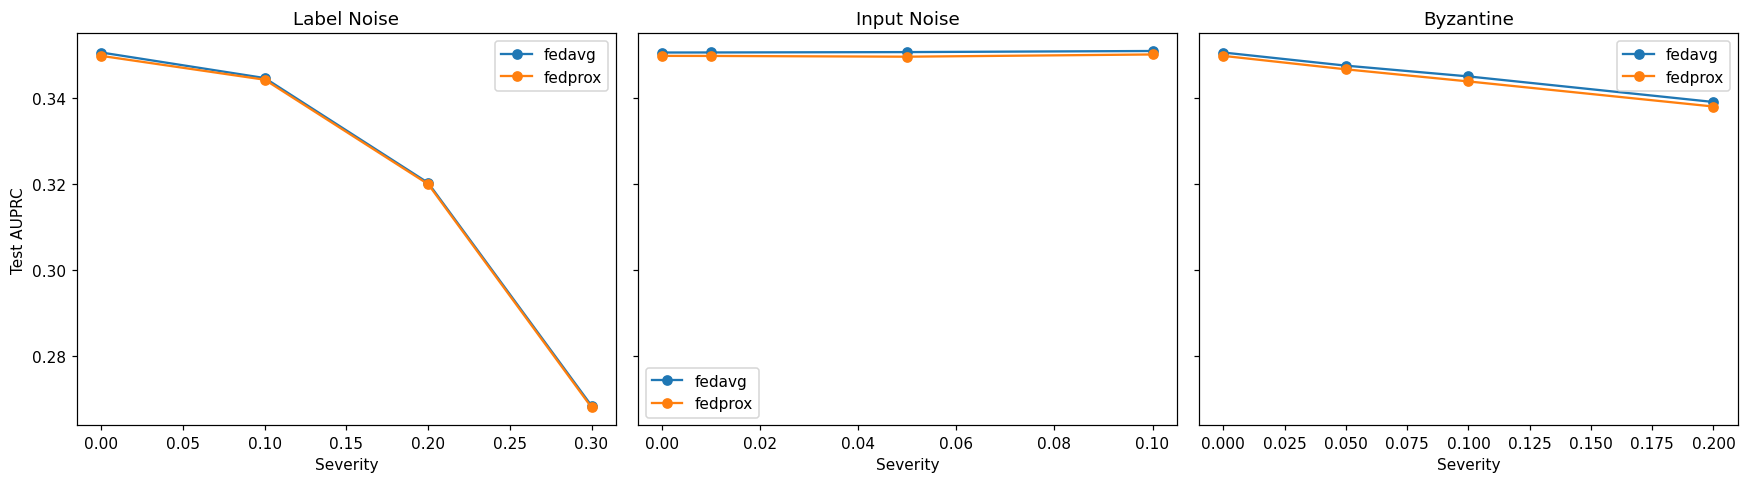

In [16]:

# Degradation curves: AUPRC vs. severity, one line per aggregator, one panel per perturbation type
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
pert_types = ["label_noise", "input_noise", "byzantine"]
severities_map = {"label_noise": LABEL_NOISE_SEVERITIES, "input_noise": INPUT_NOISE_SEVERITIES, "byzantine": BYZANTINE_SEVERITIES}
baseline_auprc = {agg: phaseC_summary_df.set_index("setting").loc[agg, "auprc_mean"] for agg in ["fedavg", "fedprox"]}

for ax, pert in zip(axes, pert_types):
    for agg in ["fedavg", "fedprox"]:
        xs = [0] + severities_map[pert]
        ys = [baseline_auprc[agg]] + [
            phaseD_summary_df[(phaseD_summary_df["perturbation"] == pert) &
                               (phaseD_summary_df["severity"] == s) &
                               (phaseD_summary_df["aggregator"] == agg)]["auprc_mean"].values[0]
            for s in severities_map[pert]
        ]
        ax.plot(xs, ys, marker="o", label=agg)
    ax.set_title(pert.replace("_", " ").title())
    ax.set_xlabel("Severity")
    ax.legend()
axes[0].set_ylabel("Test AUPRC")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "phaseD_degradation_curves.png", bbox_inches="tight")
plt.show()


## 10. Hospital-Size Stratification

No new training -- pure re-analysis of Phase D's already-computed per-hospital results, checking whether small hospitals are disproportionately vulnerable to any perturbation type.

In [21]:

median_size = qualifying_hospitals["n_stays"].median()
qualifying_hospitals = qualifying_hospitals.copy()  # avoids SettingWithCopyWarning below
qualifying_hospitals["size_group"] = np.where(qualifying_hospitals["n_stays"] >= median_size, "large", "small")
size_groups = qualifying_hospitals.set_index("hospitalid")["size_group"]
print(f"Median hospital size: {median_size:.0f} stays")
print(qualifying_hospitals["size_group"].value_counts())

strat_rows = []
for (pert_type, severity, agg_name), df_h in phaseD_per_hospital.items():
    baseline_df = phaseC_per_hospital.get(agg_name)
    if baseline_df is None:
        continue
    a = df_h.set_index("hospitalid")["auprc"]
    b = baseline_df.set_index("hospitalid")["auprc"]
    common = a.index.intersection(b.index).intersection(size_groups.index)
    delta = a.loc[common] - b.loc[common]
    groups = size_groups.loc[common]
    small_delta, large_delta = delta[groups == "small"], delta[groups == "large"]
    if len(small_delta) < 5 or len(large_delta) < 5:
        continue
    stat, p = mannwhitneyu(small_delta, large_delta, alternative="two-sided")
    strat_rows.append({"perturbation": pert_type, "severity": severity, "aggregator": agg_name,
                        "small_n": len(small_delta), "small_mean_delta": small_delta.mean(),
                        "large_n": len(large_delta), "large_mean_delta": large_delta.mean(),
                        "U_stat": stat, "p_value": p})

strat_df = pd.DataFrame(strat_rows)
strat_df.to_csv(RESULTS_DIR / "hospital_size_stratification.csv", index=False)
print(strat_df.to_string(index=False))


Median hospital size: 726 stays
size_group
large    51
small    50
Name: count, dtype: int64
perturbation  severity aggregator  small_n  small_mean_delta  large_n  large_mean_delta  U_stat  p_value
 label_noise      0.10     fedavg       50         -0.009386       51         -0.011466  1297.0 0.883893
 label_noise      0.10    fedprox       50         -0.011601       51         -0.012130  1279.0 0.981033
 label_noise      0.20     fedavg       50         -0.021021       51         -0.023706  1372.0 0.512170
 label_noise      0.20    fedprox       50         -0.020555       51         -0.026196  1404.0 0.382762
 label_noise      0.30     fedavg       50         -0.092676       51         -0.092324  1305.0 0.841188
 label_noise      0.30    fedprox       50         -0.094573       51         -0.093104  1298.0 0.878534
 input_noise      0.01     fedavg       50          0.000797       51          0.000516  1194.0 0.580896
 input_noise      0.01    fedprox       50         -0.000004       

## 11. APACHE Benchmark Comparison

Compares the deployed FedAvg model against APACHE IVa's own predicted mortality, on the exact same subset of test patients who have an APACHE score.

In [18]:

apache_cols = ["patientunitstayid", "apacheversion", "predictedhospitalmortality"]
apache = pd.read_csv(DATA_DIR / "apachePatientResult.csv", usecols=lambda c: c in apache_cols)
apache = apache[apache["predictedhospitalmortality"] != -1]
apache["version_rank"] = apache["apacheversion"].apply(lambda v: 0 if v == "IVa" else 1)
apache = apache.sort_values(["patientunitstayid", "version_rank"]).drop_duplicates(subset="patientunitstayid", keep="first")

merged = test_df[["patientunitstayid", "hospitalid", "mortality_label"]].merge(
    apache[["patientunitstayid", "predictedhospitalmortality"]], on="patientunitstayid", how="inner"
)
coverage = len(merged) / len(test_df)
print(f"APACHE coverage on test set: {len(merged)}/{len(test_df)} ({coverage:.1%})")

y_apache_true = merged["mortality_label"].values
y_apache_pred = merged["predictedhospitalmortality"].values
apache_metrics = full_metrics(y_apache_pred, y_apache_true)
print("APACHE IVa metrics:", apache_metrics)

# Re-evaluate FedAvg on the SAME subset for a fair comparison
test_subset = test_df[test_df["patientunitstayid"].isin(set(merged["patientunitstayid"]))]
X_sub, y_sub = to_tensors(test_subset, feature_cols)
fl_model_for_apache = train_federated(winning_ctor, winning_criterion_ctor, client_loaders, X_val, y_val,
                                       seed=SEEDS[0], mu=0.0, num_rounds=NUM_ROUNDS)
probs_sub, labels_sub = get_probs_labels(fl_model_for_apache, X_sub, y_sub)
fl_metrics_on_subset = full_metrics(probs_sub, labels_sub)
print("FedAvg (same subset) metrics:", fl_metrics_on_subset)

apache_comparison_df = pd.DataFrame([
    {"model": "APACHE_IVa", **apache_metrics, "coverage": coverage},
    {"model": "FedAvg", **fl_metrics_on_subset, "coverage": coverage},
])
apache_comparison_df.to_csv(RESULTS_DIR / "apache_comparison.csv", index=False)
print(apache_comparison_df.to_string(index=False))

# per-hospital Wilcoxon
apache_per_hosp = []
for hosp_id, group in merged.groupby("hospitalid"):
    yh, ph = group["mortality_label"].values, group["predictedhospitalmortality"].values
    if yh.sum() == 0 or yh.sum() == len(yh):
        continue
    apache_per_hosp.append({"hospitalid": hosp_id, "auprc": average_precision_score(yh, ph)})
apache_per_hosp_df = pd.DataFrame(apache_per_hosp)

fl_per_hosp_df = evaluate_per_hospital(fl_model_for_apache, test_subset, feature_cols)
a = fl_per_hosp_df.set_index("hospitalid")["auprc"]
b = apache_per_hosp_df.set_index("hospitalid")["auprc"]
common = a.index.intersection(b.index)
stat, p, r = wilcoxon_effect_size(a.loc[common], b.loc[common])
print(f"\nWilcoxon FedAvg vs APACHE: W={stat:.2f}, p={p:.6f}, r={r:.3f}, n_hospitals={len(common)}")


APACHE coverage on test set: 16635/19882 (83.7%)
APACHE IVa metrics: {'accuracy': 0.910790501953712, 'precision': 0.5048966267682263, 'recall': 0.31078365706630945, 'f1': 0.384742951907131, 'auroc': 0.8490873139061406, 'auprc': 0.4086825279850078}
FedAvg (same subset) metrics: {'accuracy': 0.9017132551848512, 'precision': 0.4327651515151515, 'recall': 0.3060951105157401, 'f1': 0.35857198901530013, 'auroc': 0.8159073784471946, 'auprc': 0.3596016026436574}
     model  accuracy  precision   recall       f1    auroc    auprc  coverage
APACHE_IVa  0.910791   0.504897 0.310784 0.384743 0.849087 0.408683  0.836686
    FedAvg  0.901713   0.432765 0.306095 0.358572 0.815907 0.359602  0.836686

Wilcoxon FedAvg vs APACHE: W=1631.00, p=0.010864, r=0.260, n_hospitals=96


## 12. Explainable AI: Feature Importance

Coefficient-based feature importance on the deployed FedAvg model, trained with L2 regularization to address one-hot identifiability and rare-category overfitting.

                                                                                                                        feature  coefficient      direction  train_n_positive
                          dx_Cardiac arrest (with or without respiratory arrest; for respiratory arrest see Respiratory System)     0.383507 increases risk            1841.0
                                                                                 dx_CABG alone, coronary artery bypass grafting    -0.303248 decreases risk            2258.0
                                                                                                       dx_Diabetic ketoacidosis    -0.297027 decreases risk            1526.0
                                                                                                                       dx_Other    -0.276278 decreases risk           34683.0
                                                                                                          dx_Bleeding, upper GI   

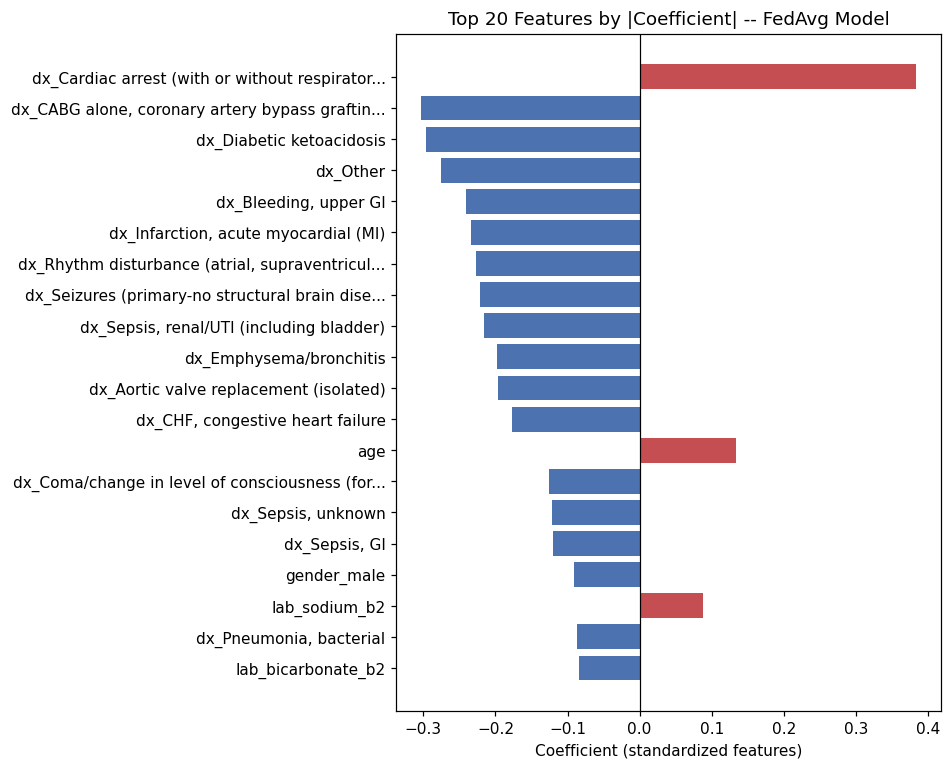

In [22]:

xai_model = train_federated(winning_ctor, winning_criterion_ctor, client_loaders, X_val, y_val,
                             seed=SEEDS[0], mu=0.0, weight_decay=1e-3, num_rounds=NUM_ROUNDS)

if winning_model_name == "LR":
    weights = xai_model.linear.weight.detach().cpu().numpy().flatten()
    bias = xai_model.linear.bias.item()

    train_counts = {}
    for col in feature_cols:
        if col.startswith(("dx_", "unittype_", "gender_")):
            train_counts[col] = int(train_df[col].sum()) if col in train_df.columns else np.nan
        else:
            train_counts[col] = np.nan

    importance_df = pd.DataFrame({
        "feature": feature_cols, "coefficient": weights, "abs_coefficient": np.abs(weights),
        "train_n_positive": [train_counts[c] for c in feature_cols],
    }).sort_values("abs_coefficient", ascending=False)
    importance_df["direction"] = np.where(importance_df["coefficient"] > 0, "increases risk", "decreases risk")
    importance_df.to_csv(RESULTS_DIR / "feature_importance_full.csv", index=False)

    top20 = importance_df.head(20)
    top20.to_csv(RESULTS_DIR / "feature_importance_top20.csv", index=False)
    print(top20[["feature", "coefficient", "direction", "train_n_positive"]].to_string(index=False))

    fig, ax = plt.subplots(figsize=(11, 8))
    colors = ["#C44E52" if c > 0 else "#4C72B0" for c in top20["coefficient"][::-1]]
    # truncate long labels for display only -- full feature names remain in the saved CSV
    display_labels = [f[:45] + "..." if len(f) > 45 else f for f in top20["feature"][::-1]]
    ax.barh(display_labels, top20["coefficient"][::-1], color=colors)
    ax.set_xlabel("Coefficient (standardized features)")
    ax.set_title("Top 20 Features by |Coefficient| -- FedAvg Model")
    ax.axvline(0, color="black", linewidth=0.8)
    plt.subplots_adjust(left=0.45)
    plt.savefig(FIGURE_DIR / "xai_feature_importance.png", bbox_inches="tight")
    plt.show()
else:
    print(f"Coefficient-based XAI implemented for LR only. Winning model is {winning_model_name} -- "
          "use permutation importance or SHAP instead if a non-linear model was selected.")


## 13. Final Consolidated Summary

All key results in one place, for direct use in the paper's tables and figures.

In [20]:

print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print("\n--- Phase A: Architecture Sweep ---")
print(phaseA_summary_df[["model", "n_params", "auprc_mean", "auprc_std", "auroc_mean", "f1_mean"]].to_string(index=False))

print("\n--- Phase B: Class Imbalance Handling ---")
print(phaseB_summary_df[["config", "auprc_mean", "auroc_mean", "f1_mean"]].to_string(index=False))

print("\n--- Phase C: Centralized vs. Federated (natural conditions) ---")
print(phaseC_summary_df[["setting", "auprc_mean", "auroc_mean", "f1_mean"]].to_string(index=False))

print("\n--- Communication Overhead ---")
print(comm_df.to_string(index=False))

print("\n--- Inference Latency ---")
print(latency_df.to_string(index=False))

print("\n--- Phase D: Robustness (selected rows) ---")
print(phaseD_summary_df[["perturbation", "severity", "aggregator", "auprc_mean", "f1_mean"]].to_string(index=False))

print("\n--- APACHE Comparison ---")
print(apache_comparison_df.to_string(index=False))

print("\nAll results saved to:", RESULTS_DIR.resolve())
print("All figures saved to:", FIGURE_DIR.resolve())


FINAL SUMMARY

--- Phase A: Architecture Sweep ---
    model  n_params  auprc_mean  auprc_std  auroc_mean  f1_mean
       LR       392    0.372117   0.001532    0.816666 0.230232
      MLP     27201    0.402185   0.005000    0.831506 0.277099
CNN_light       593    0.203210   0.007668    0.690958 0.028766
CNN_heavy      8513    0.207147   0.000476    0.692359 0.042829

--- Phase B: Class Imbalance Handling ---
        config  auprc_mean  auroc_mean  f1_mean
    unweighted    0.372117    0.816666 0.230232
class_weighted    0.359443    0.818833 0.341195
         focal    0.362928    0.814789 0.385707

--- Phase C: Centralized vs. Federated (natural conditions) ---
    setting  auprc_mean  auroc_mean  f1_mean
centralized    0.362928    0.814789 0.385707
     fedavg    0.350653    0.811772 0.356733
    fedprox    0.349868    0.811062 0.356091

--- Communication Overhead ---
setting  model_size_MB  per_round_MB  total_MB_full_budget  n_clients  n_rounds
 fedavg       0.001568      0.316736 